Continuation of the fte_modified_gates_NaK.ipynb notebook. It contains a lot of experiments with different channel types, training lengths, and hyperparameters, but it is easy to set up a new experiment as well.

In [4]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"


%load_ext autoreload
%autoreload 2



from jax import config
config.update("jax_enable_x64", True)


import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx

import jax.random as jr
from typing import List


import equinox as eqx
import flax.nnx as nnx


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Let's see the data!

In [5]:
t_max = 130.0
cut = 1500  # We cut the first 1500 datapoints because this period contains no stimulus

# setup = "488683425"
# setup = "485574832"
# setup = "480353286"
setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data
)

t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.17000000178813934


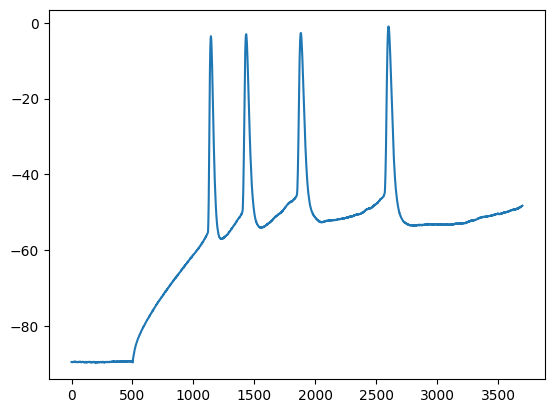

In [6]:
plt.plot(v_data[0])

In [7]:
# Define the single-compartment cell to train
from voltage_fitting.single_build_simulator import (
    setup_Na_K_simulator,
    setup_Na_K_simulator_step,
    build_Na_K_cell,
    set_setup,
    get_Na_K_bounds,
    transform_uniform_to_normal,
    get_prior
)

from voltage_fitting.loss_util import (
    get_scaled_loss,
)

seed = 7

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], use_CaT=True, use_CaL=False, use_Km=True)
simulate_single = setup_Na_K_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_Na_K_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0], gating = False)[0]

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 11


In [8]:
inv_sampled_params

Array([-6.54385118e+01, -7.87579094e+01,  5.46316403e+01,  1.24613302e+02,
        4.51082003e+03,  4.40699708e-02,  9.41859735e-03,  2.65789794e-05,
        2.36042699e-05,  9.26924336e-05,  1.76721129e+02], dtype=float64)

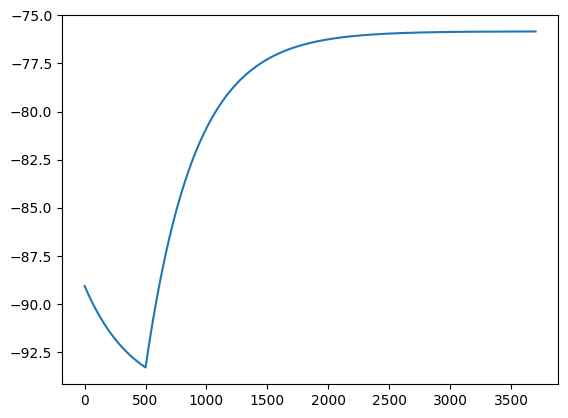

In [9]:
plt.plot(v_single[0])

In [ ]:
# Simulate 3000 times with random parameters

from voltage_fitting.posthoc_summary_stats import (
    find_spikes,
    spike_count,
    first_spike_time,
    second_spike_time,
    first_spike_amp,
    second_spike_amp,
)

cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], use_CaT=True, use_CaL=True, use_Km=True)

n_params = 3_000
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_params)
)

def predict(params):
    inv_params = inv_transform_params(params)
    simulate_single = setup_Na_K_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0])[0][0]
    return v

vmapped_predict = jax.vmap(predict)
x_preds = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_preds, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_preds, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_preds, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)

vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_preds, 1.0, 0.05, 1.0)#, cost_fn_power=1.0, scale=0.05, penalty_rate=1.0)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


Initialization with different channel sets

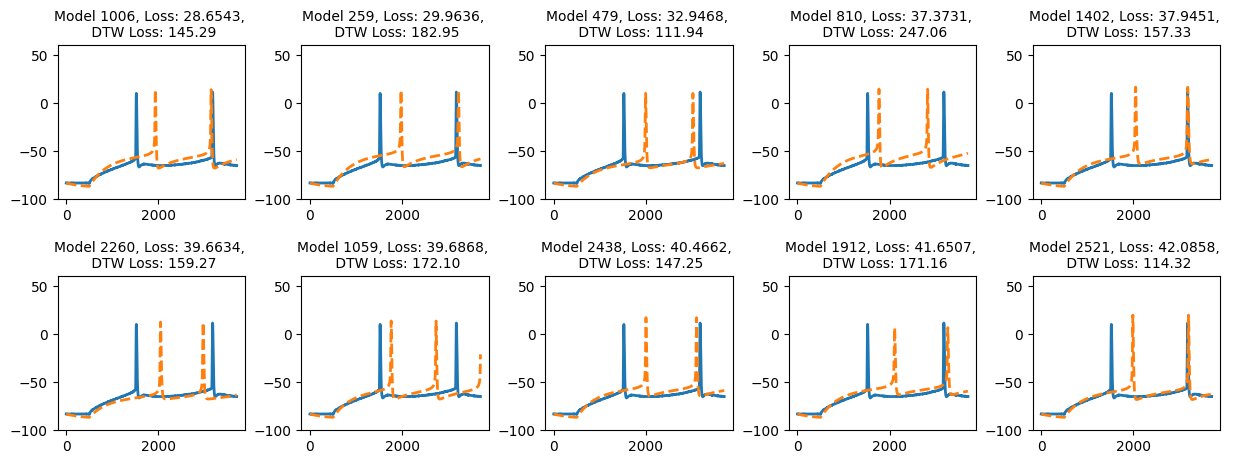

In [ ]:
#25: 10 best results based on summed errors, t = 130.0
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

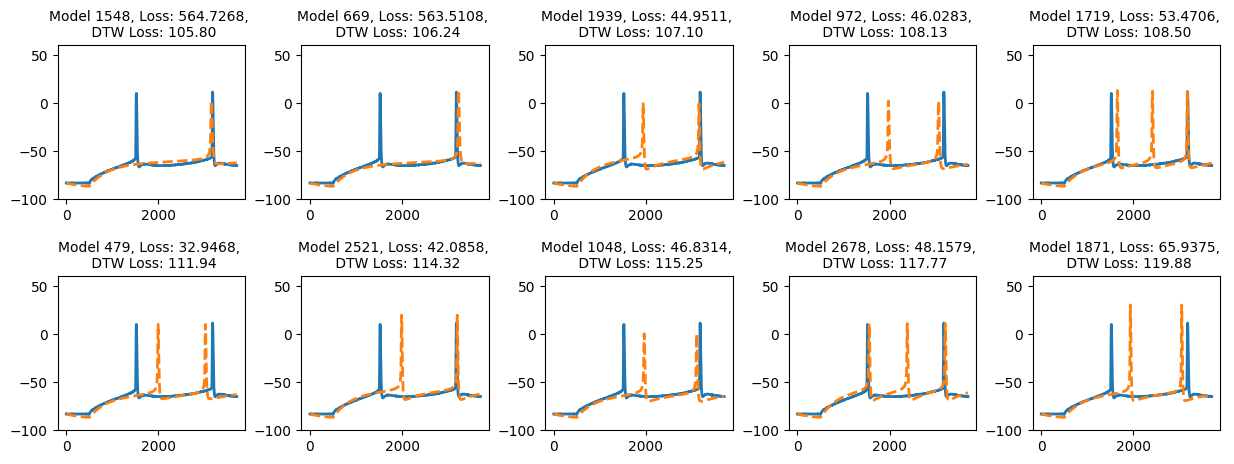

In [ ]:
#25: 10 best results based on dtw loss, t = 130.0
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

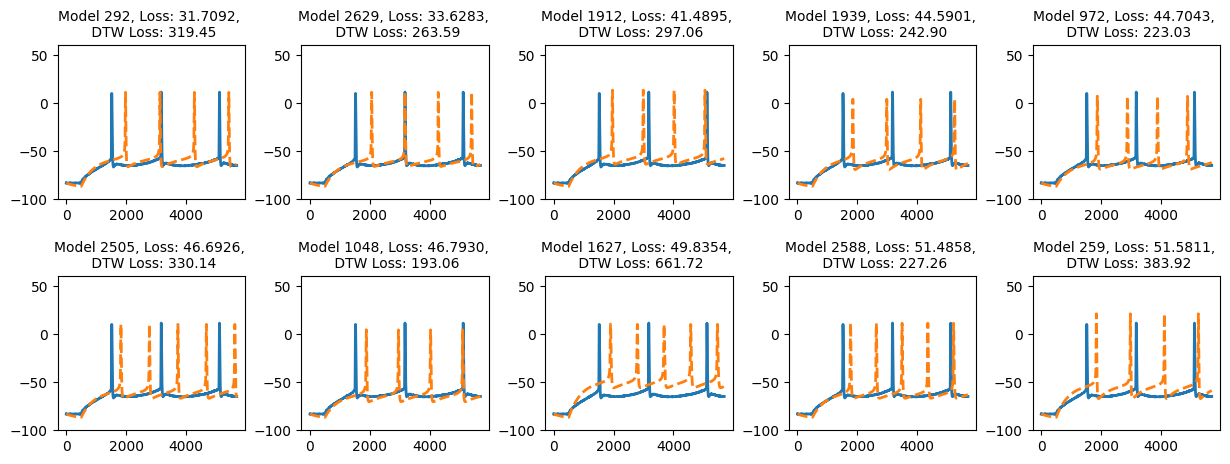

In [ ]:
#25: 10 best results based on summed errors, t = 180.0
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

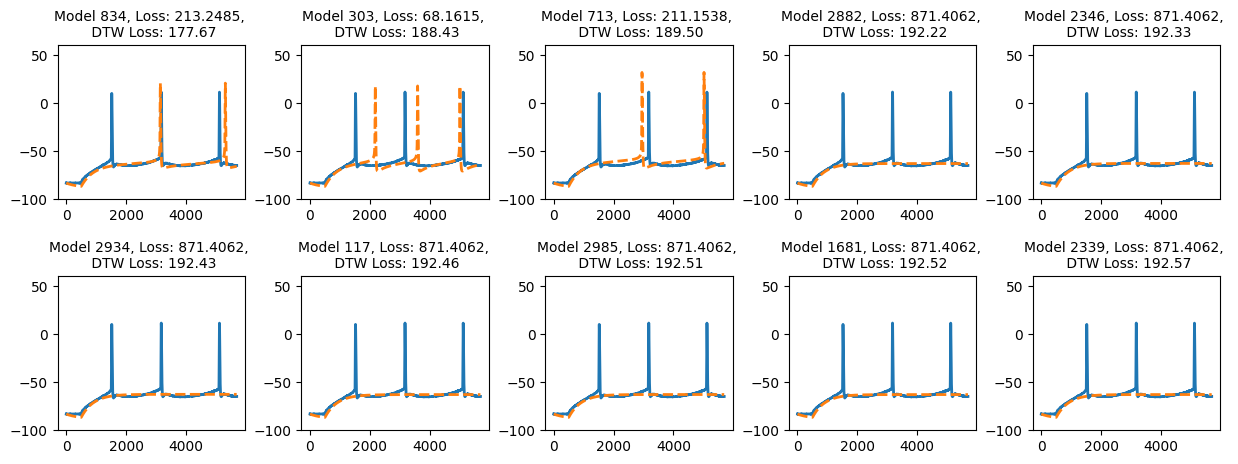

In [ ]:
#25: 10 best results based on dtw loss, t = 180.0
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

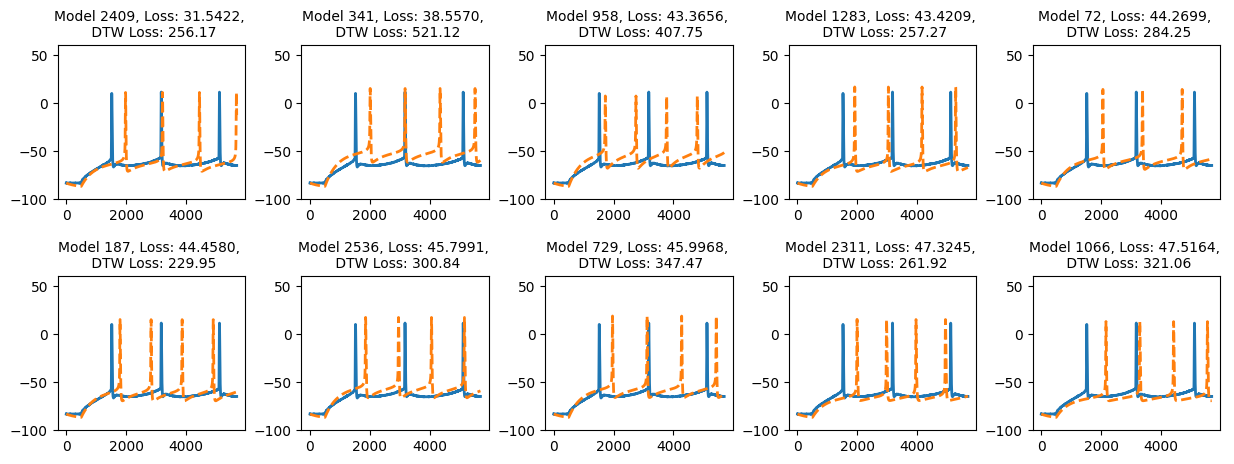

In [ ]:
#25: 10 best results based on summed errors, t = 180.0, with Km
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

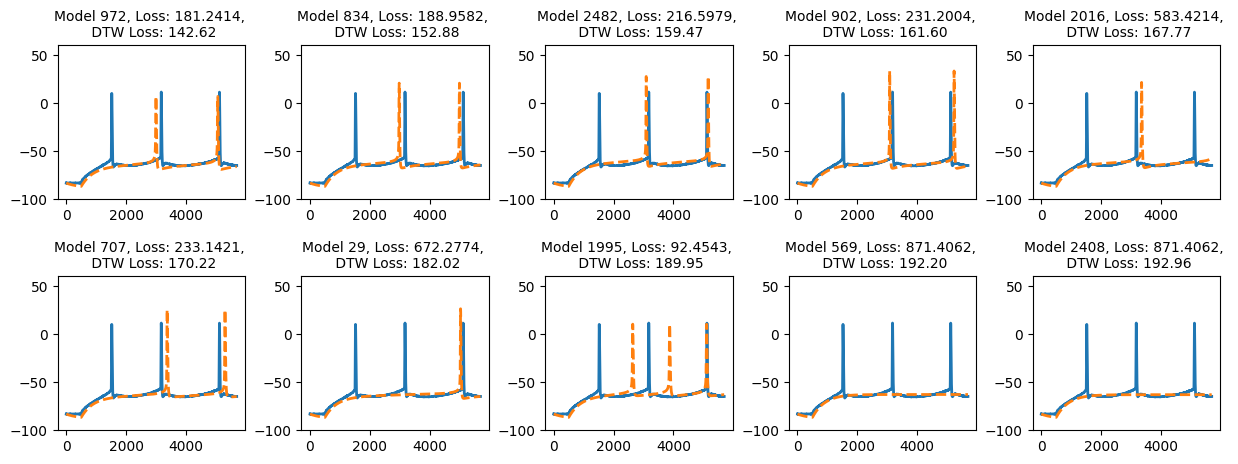

In [ ]:
#25: 10 best results based on dtw loss, t = 180.0, with Km
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

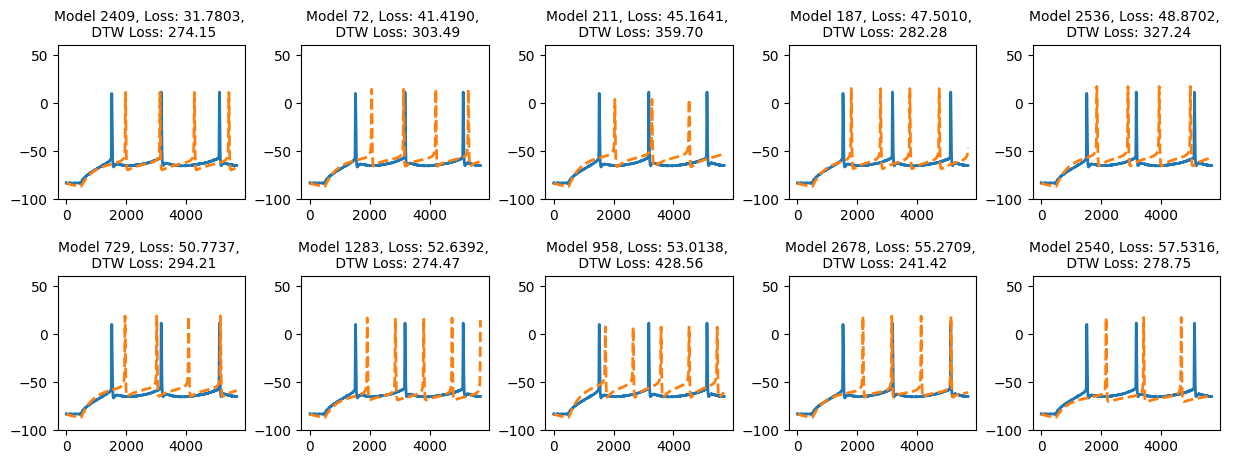

In [ ]:
#25: 10 best results based on summed errors, t = 180.0, with Km, with CaL
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

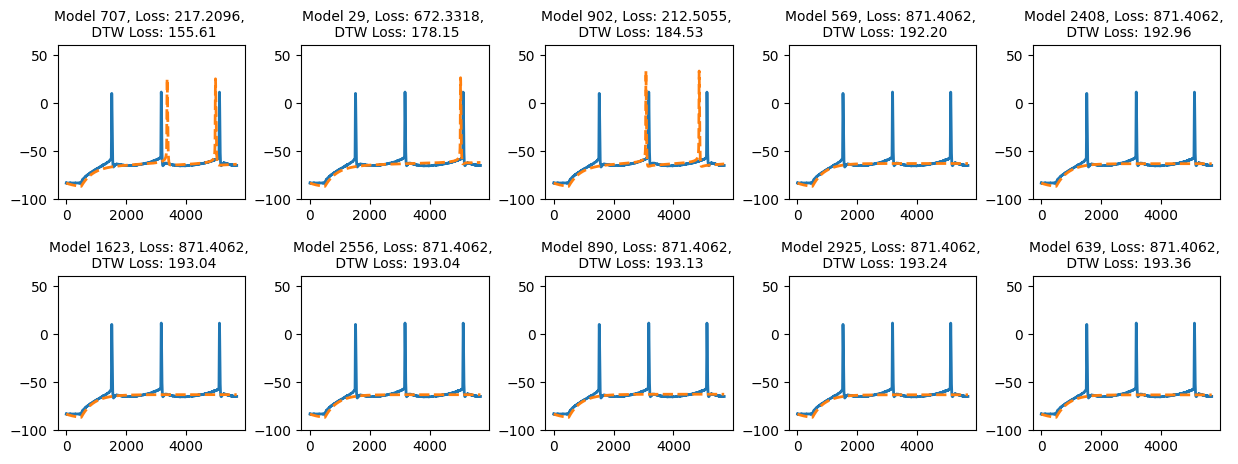

In [ ]:
#25: 10 best results based on dtw loss, t = 180.0, with Km, with CaL
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

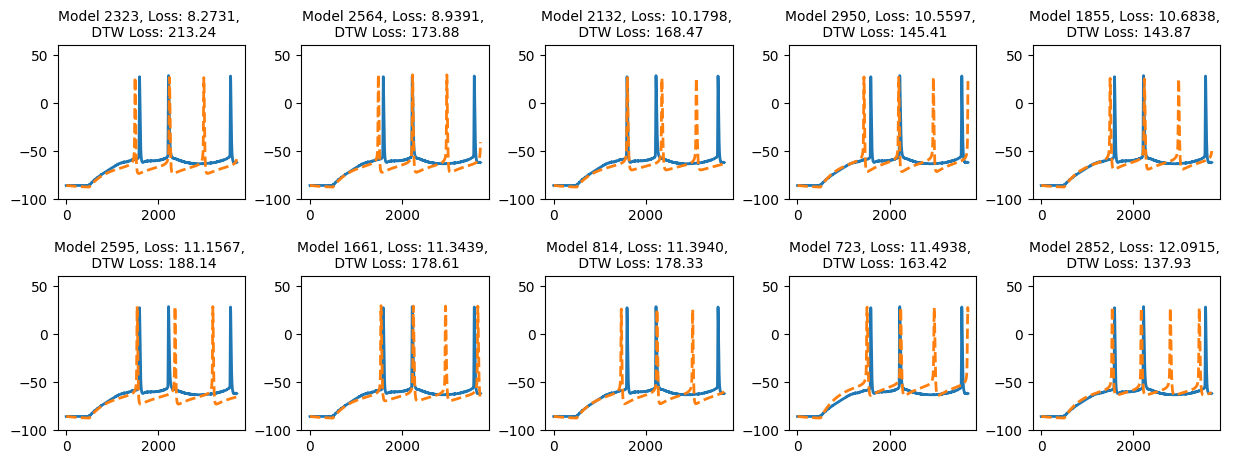

In [ ]:
#32: 10 best results based on summed errors 
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

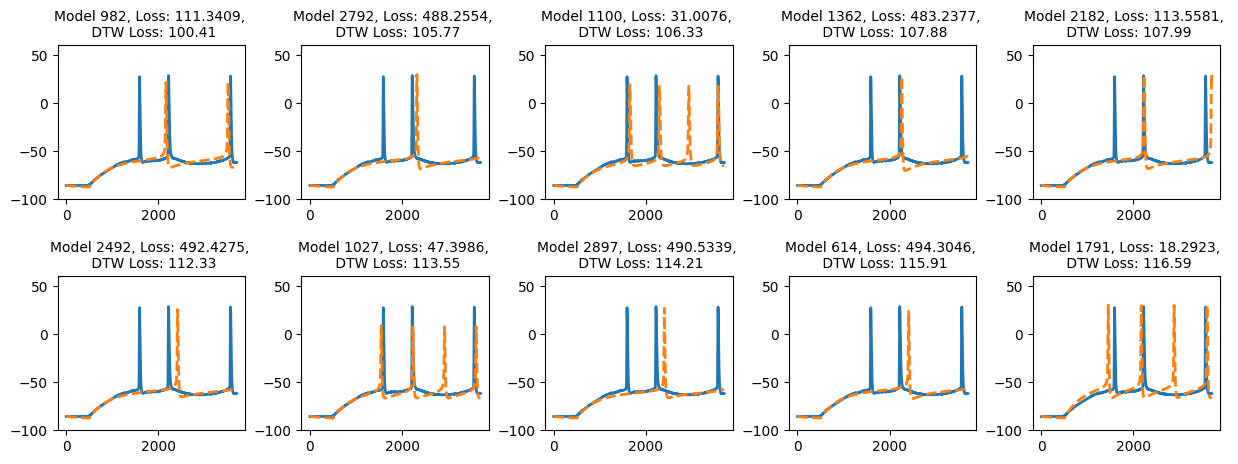

In [ ]:
#32: 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

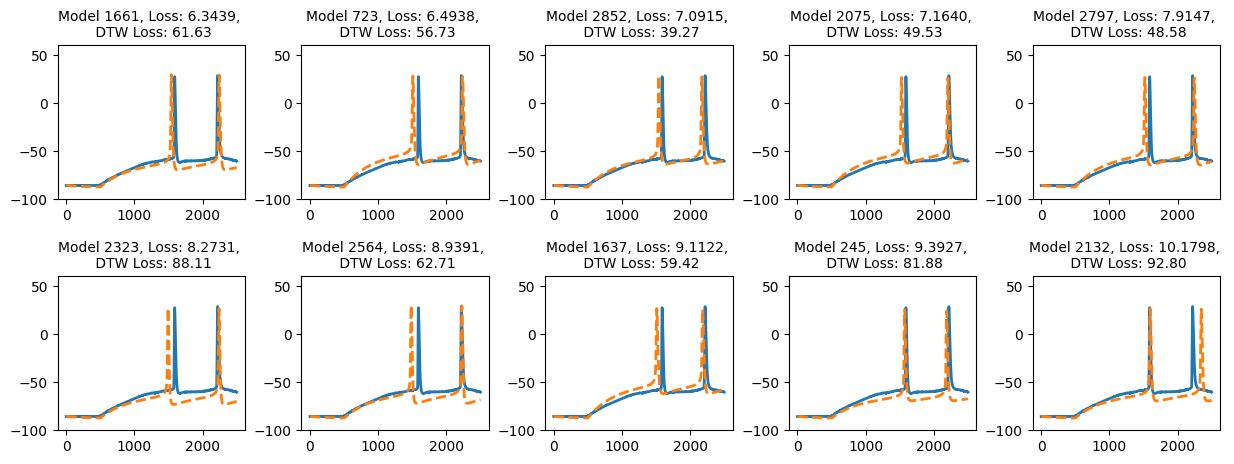

In [ ]:
#32: 10 best results based on summed errors, t = 100.0
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

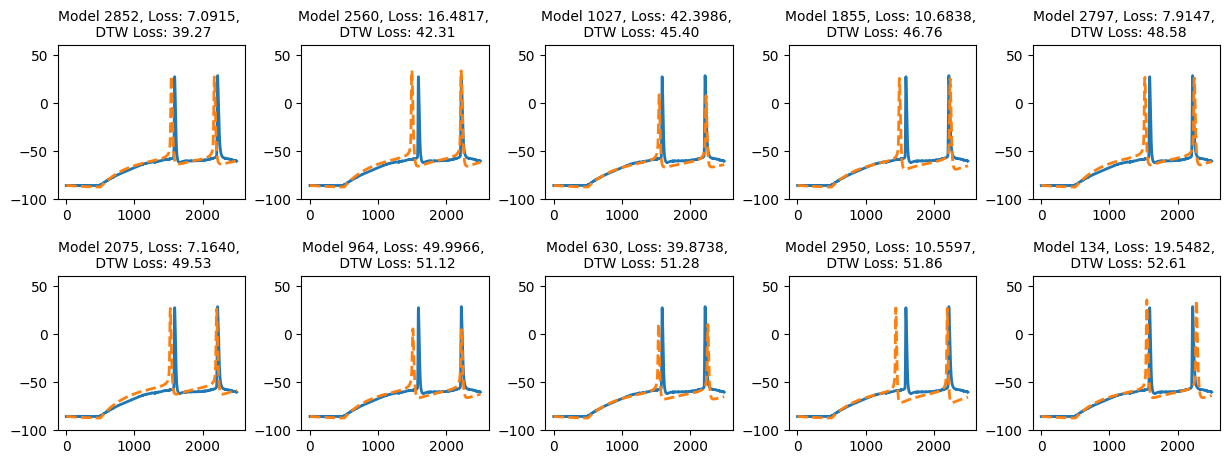

In [ ]:
#32: 10 best results based on dtw loss, t=100.0
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

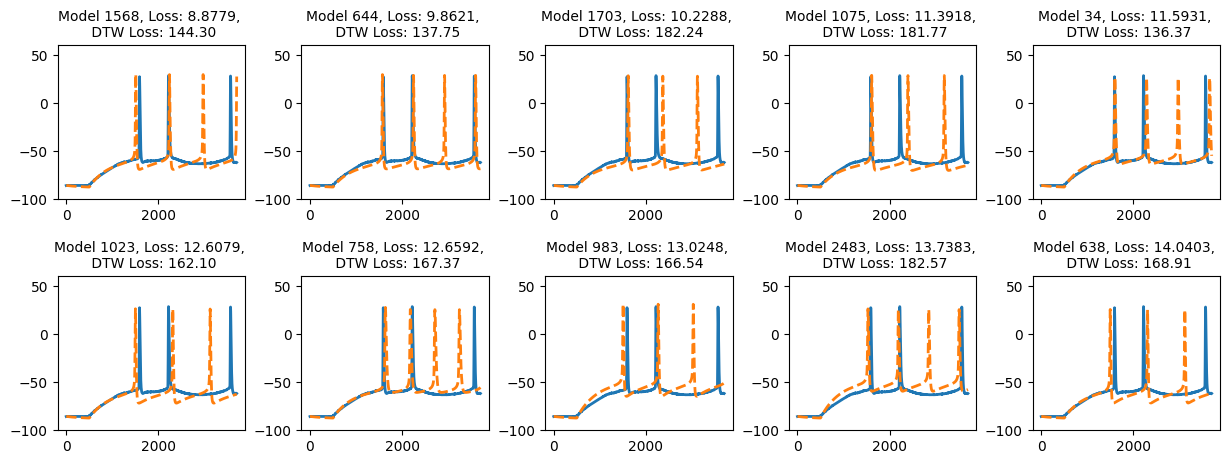

In [ ]:
#32: 10 best results based on summed errors, t = 130.0, with Km
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

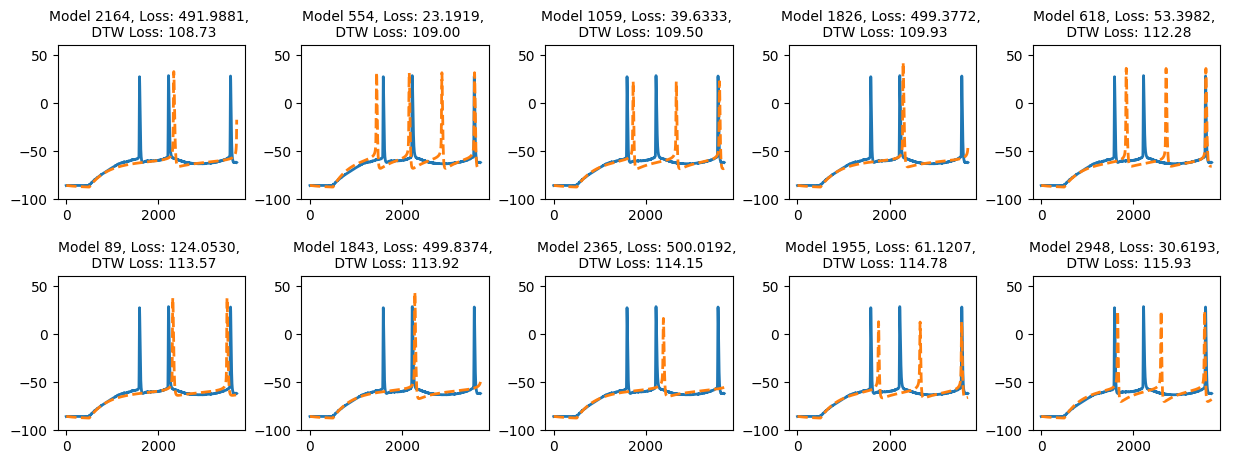

In [ ]:
#32: 10 best results based on dtw loss, t=130.0, with Km
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

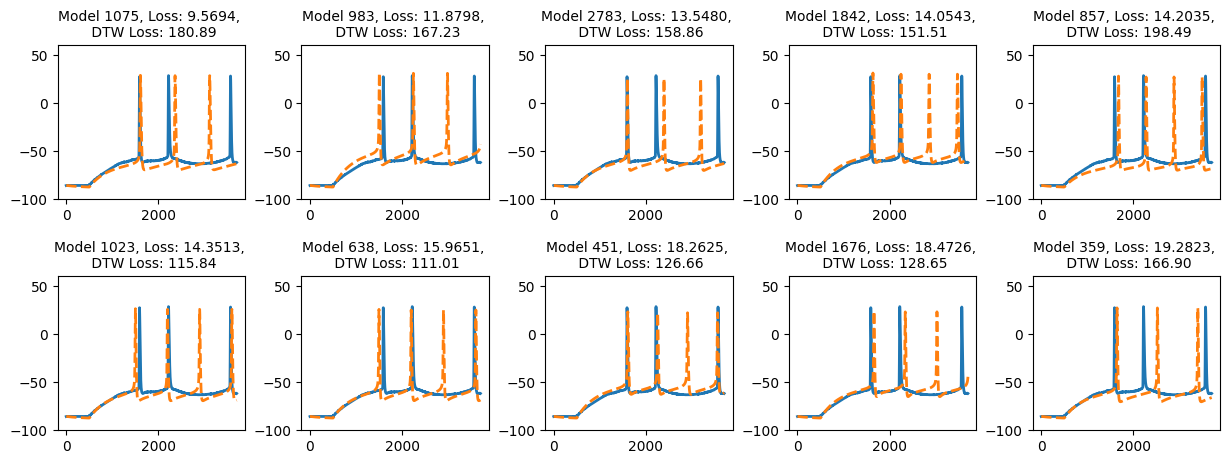

In [ ]:
#32: 10 best results based on summed errors, t = 130.0, with Km, with CaL
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

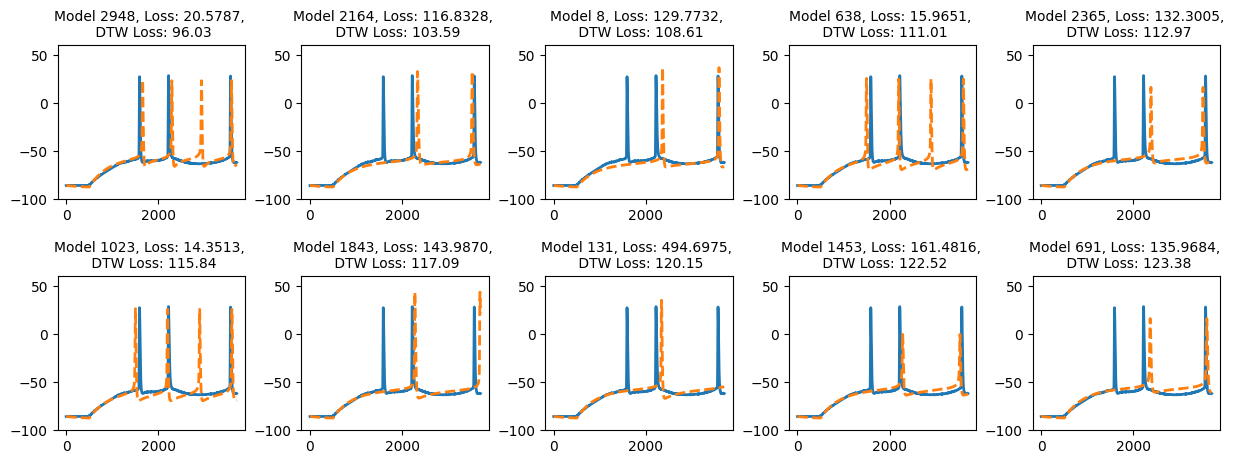

In [ ]:
#32: 10 best results based on dtw loss, t=130.0, with Km, with CaL
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

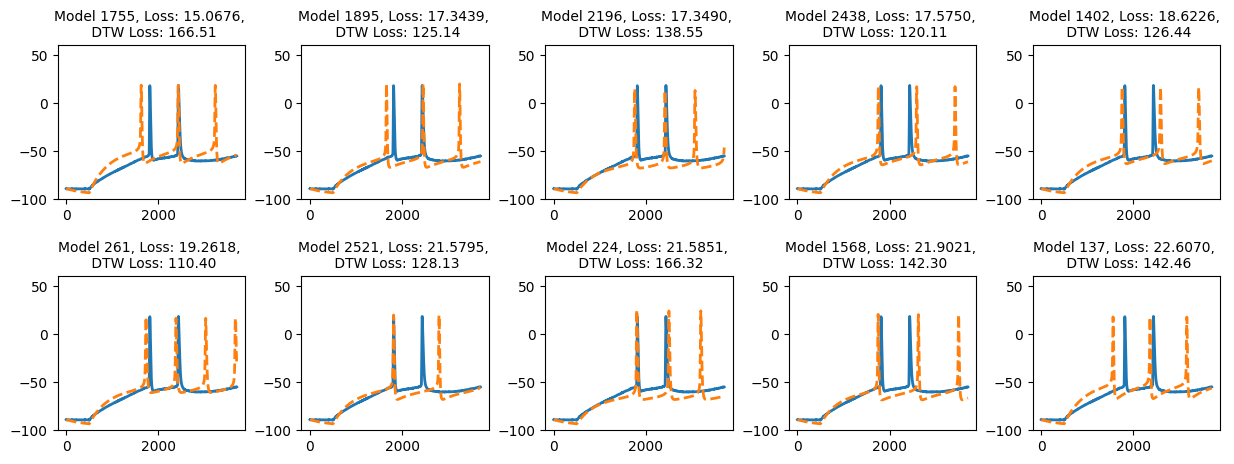

In [ ]:
#86: 10 best results based on summed errors, t=130.0
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

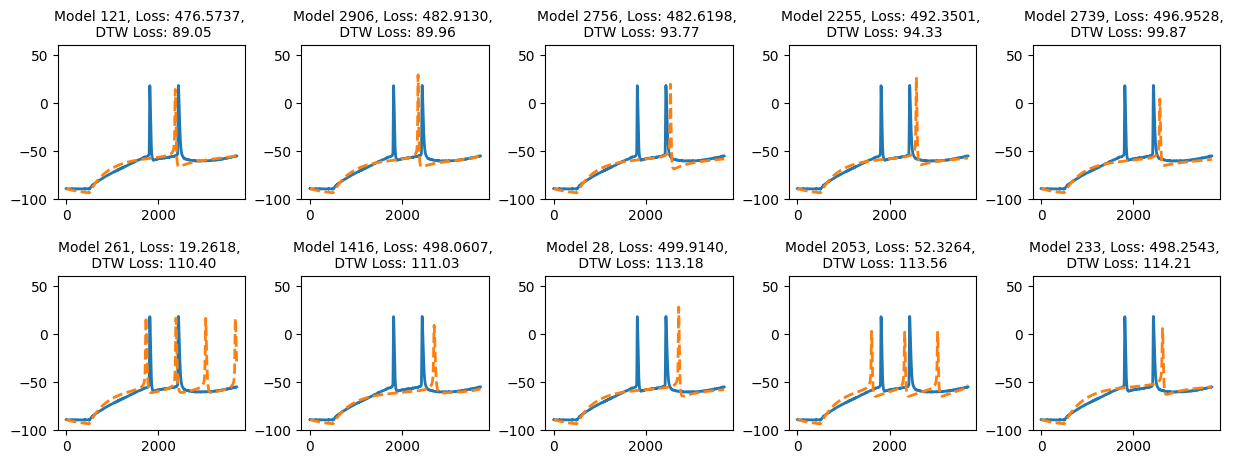

In [ ]:
#86: 10 best results based on dtw loss, t=130.0
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

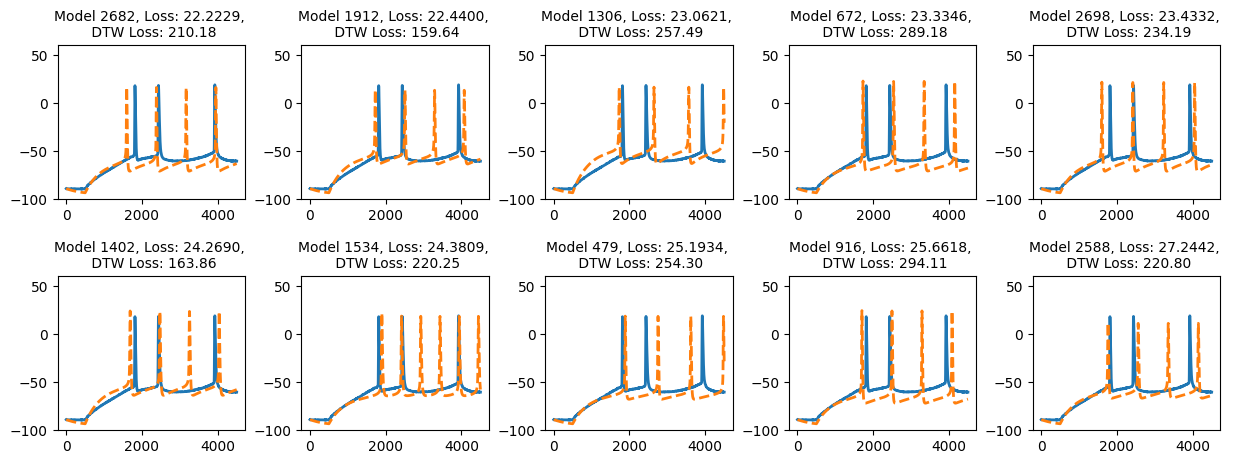

In [ ]:
#86: 10 best results based on summed errors, t=150.0
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

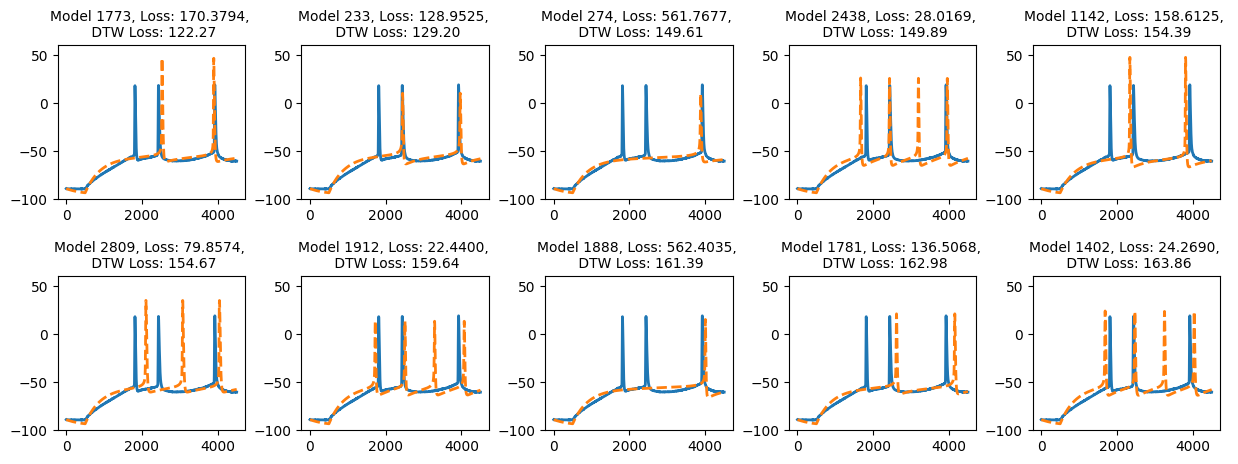

In [ ]:
#86: 10 best results based on dtw loss, t=150.0
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

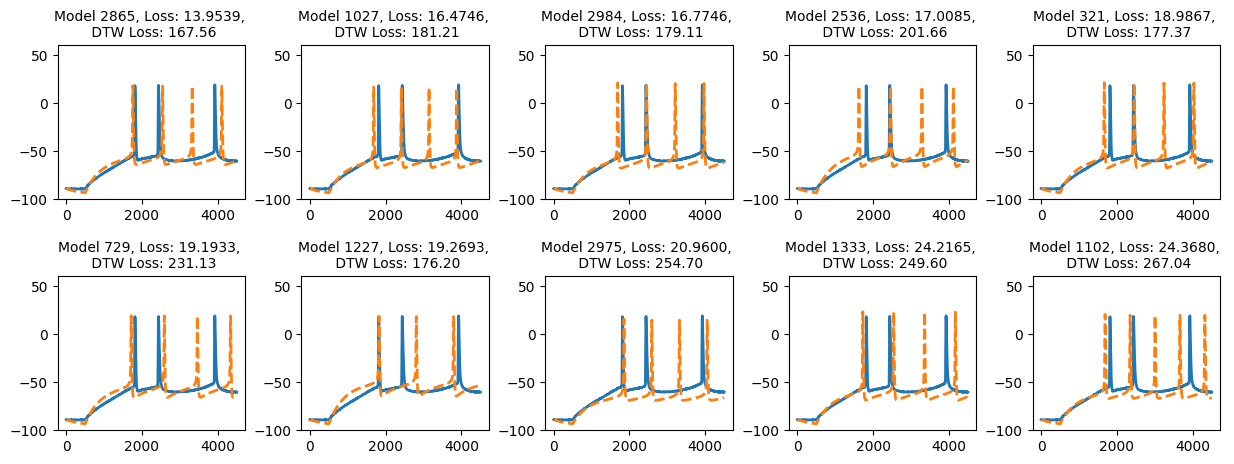

In [ ]:
#86: 10 best results based on summed errors, t=150.0, with Km
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

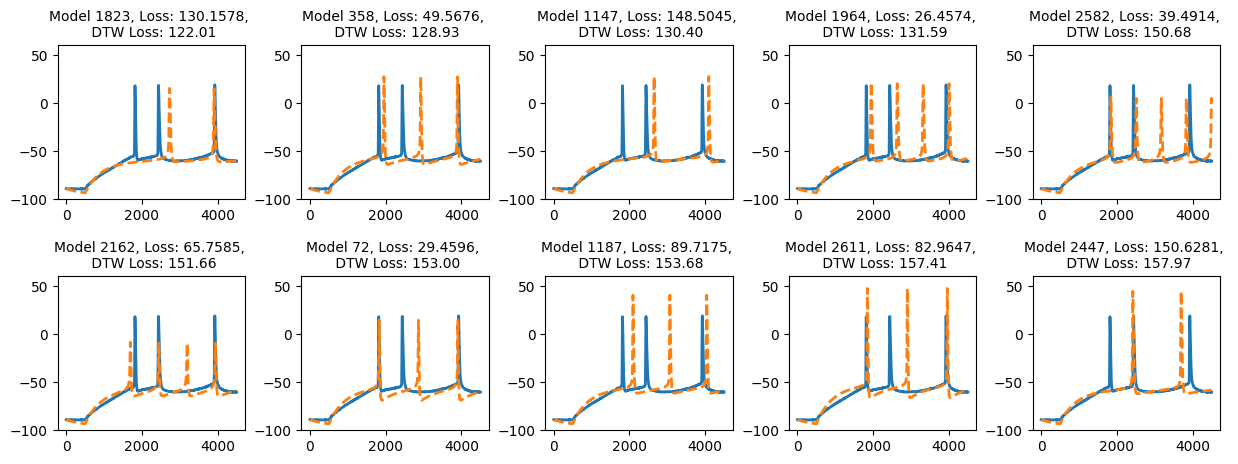

In [ ]:
#86: 10 best results based on dtw loss, t=150.0, with Km
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

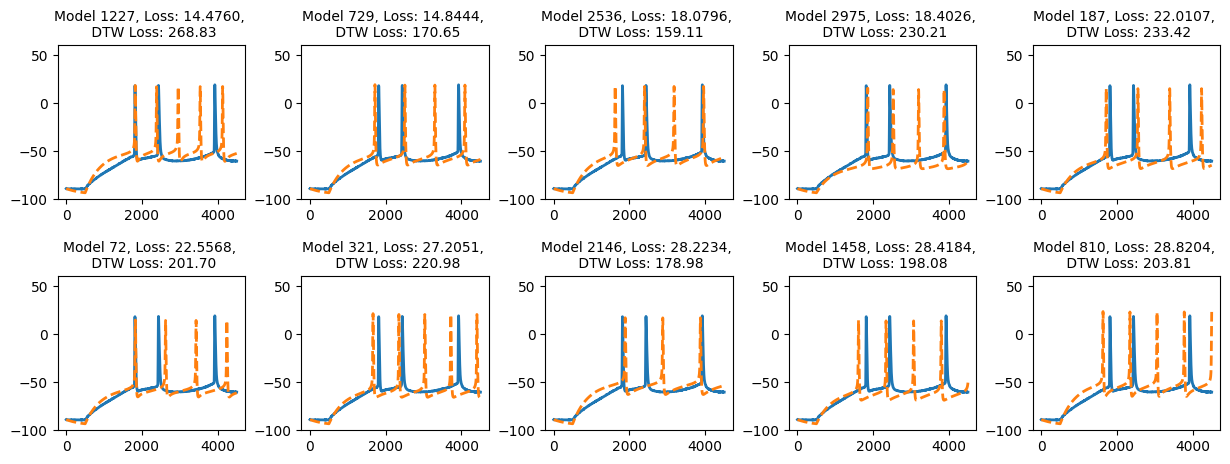

In [ ]:
#86: 10 best results based on summed errors, t=150.0, with Km, with CaL
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

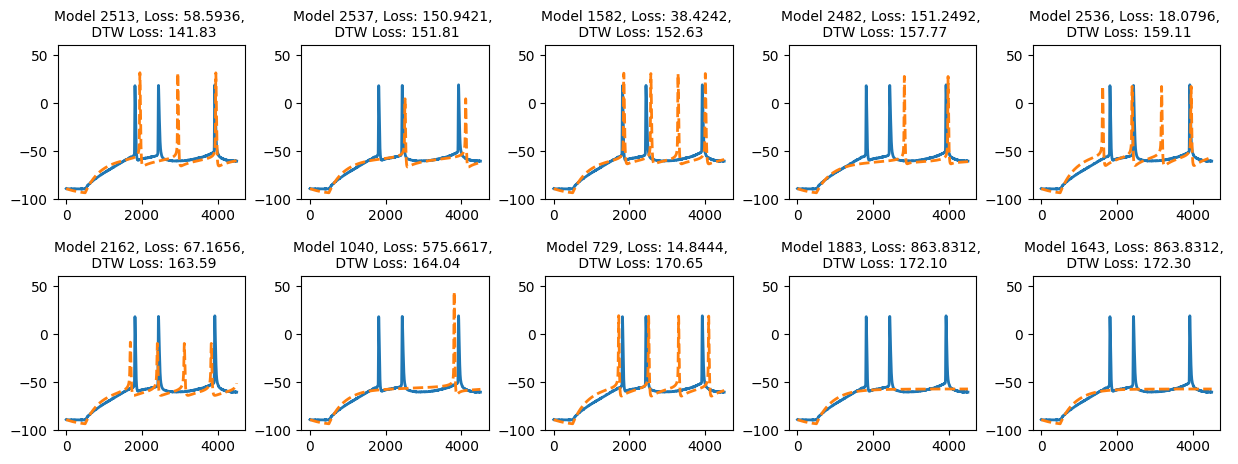

In [ ]:
#86: 10 best results based on dtw loss, t=150.0, with Km, with CaL
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

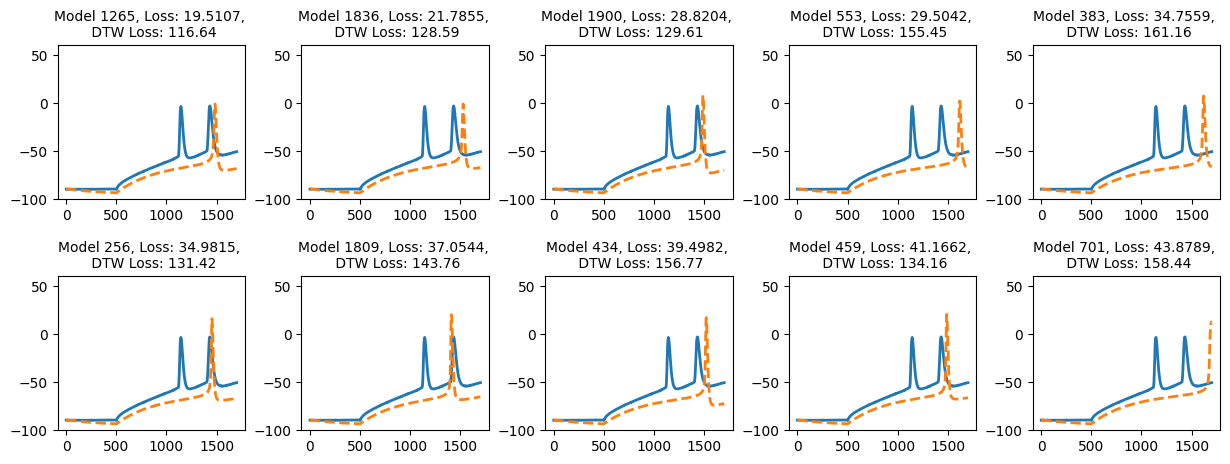

In [ ]:
#79: 10 best results based on summed errors, t = 80.0
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

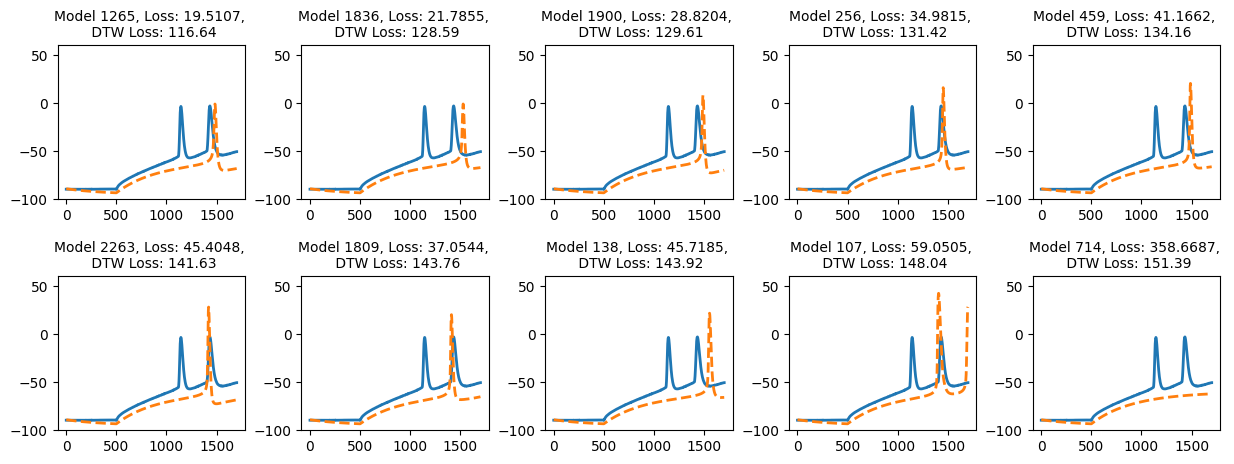

In [ ]:
#79: 10 best results based on dtw loss, t = 80.0
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

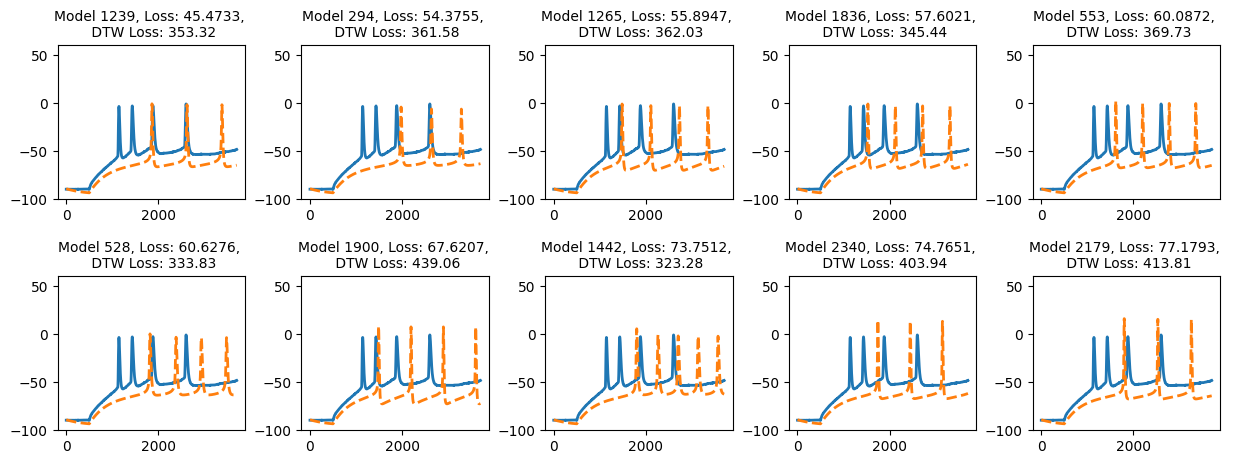

In [ ]:
#79: 10 best results based on summed errors, t = 130.0
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

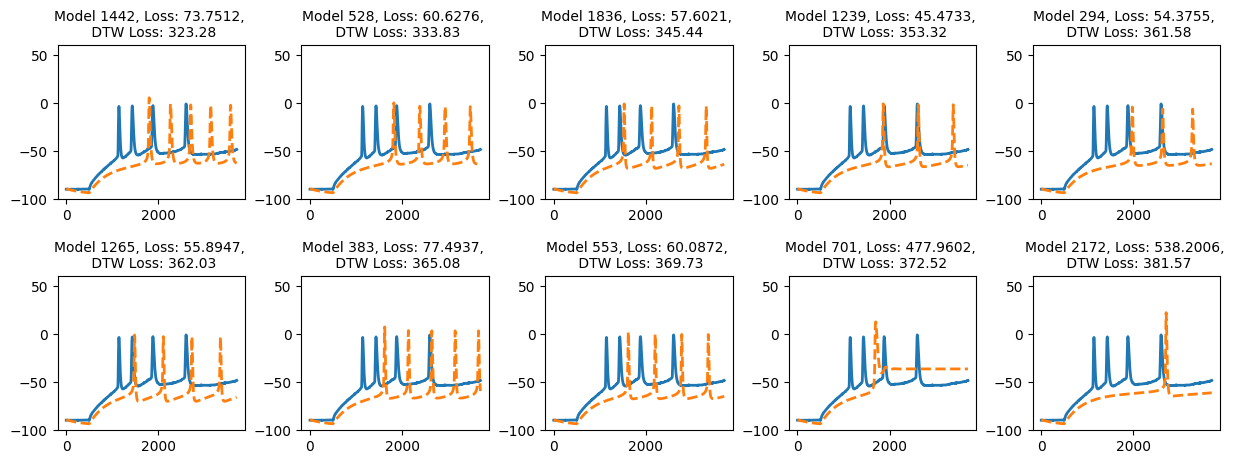

In [ ]:
#79: 10 best results based on dtw loss, t = 130.0
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

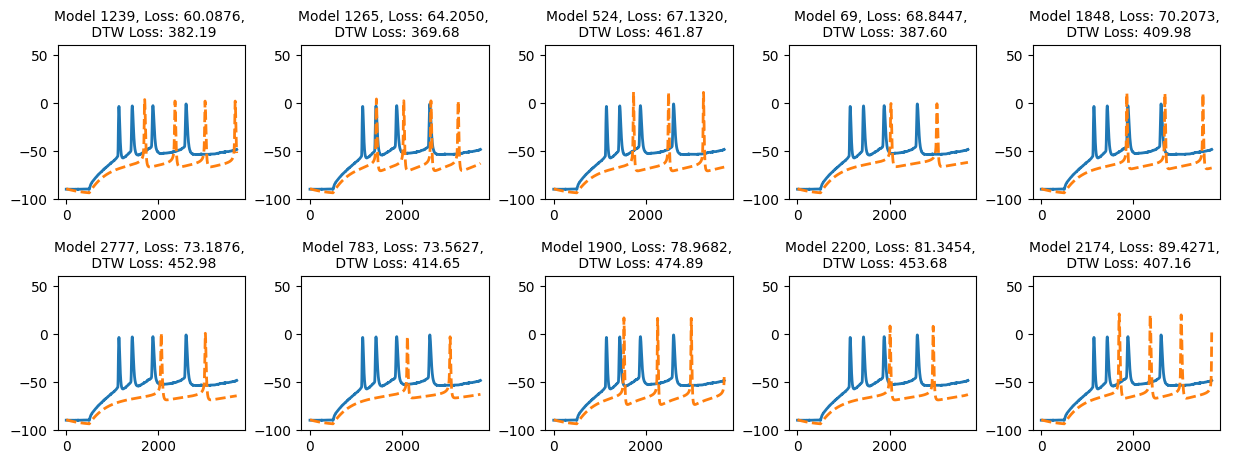

In [ ]:
#79: 10 best results based on summed errors, t = 130.0, with Km
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

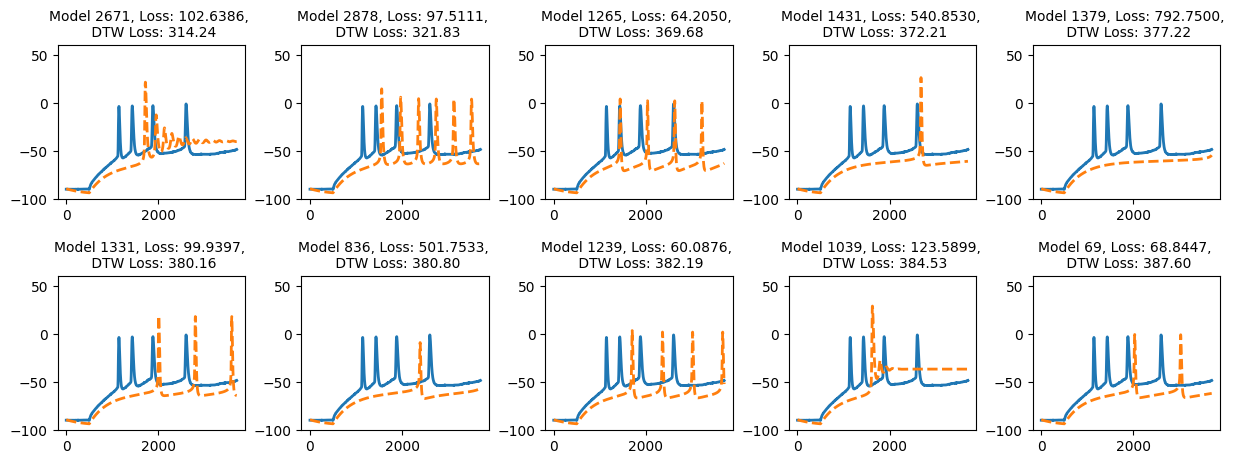

In [ ]:
#79: 10 best results based on dtw loss, t = 130.0, with Km
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

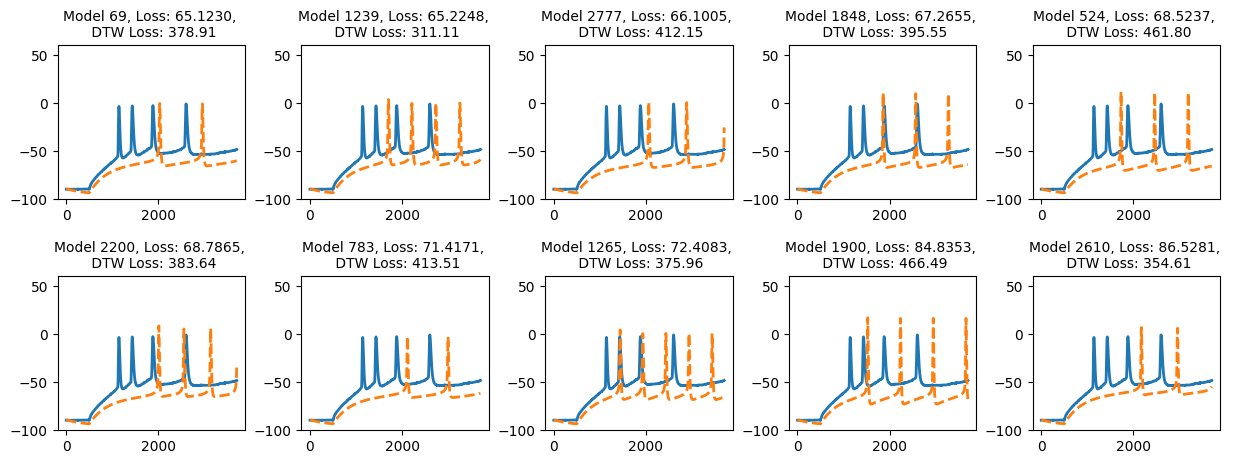

In [ ]:
#79: 10 best results based on summed errors, t = 130.0, with Km, with CaL
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

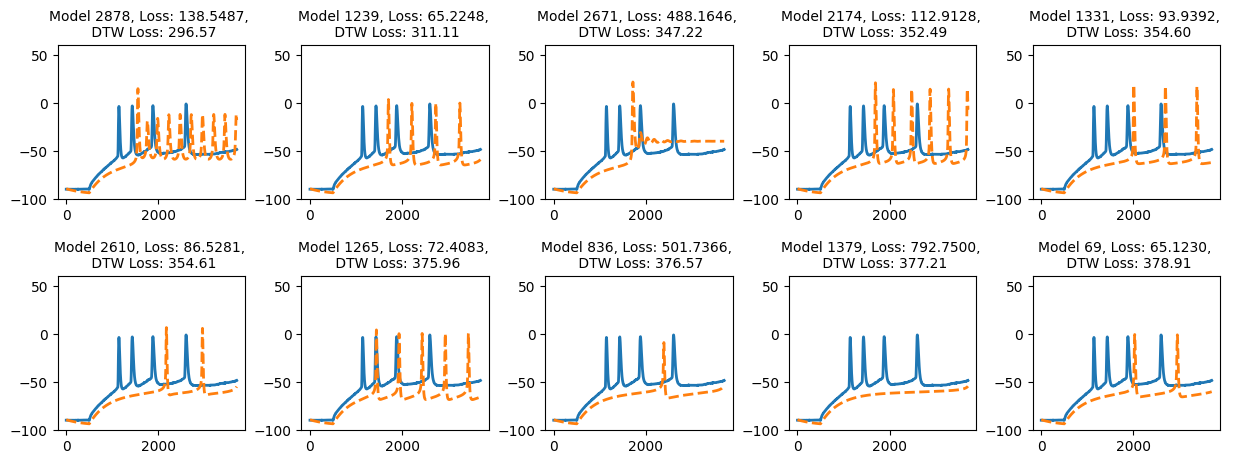

In [ ]:
#79: 10 best results based on dtw loss, t = 130.0, with Km, with CaL
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**Initialization of the NNs**

In [10]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices,
)

key = jax.random.PRNGKey(0)
dt = 0.025
u_dimension = 8
n_particles = 300 

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   
    h=dt,
    u_dim=u_dimension,
    use_complex=True
)

print("1st Sampled Eigenvalues:")
for e in eigs:
    print(e, ", scaled with dt: ", dt*e)

1st Sampled Eigenvalues:
(-42.141613528976286-22.98417698424073j) , scaled with dt:  (-1.0535403382244073-0.5746044246060182j)
(-42.141613528976286+22.98417698424073j) , scaled with dt:  (-1.0535403382244073+0.5746044246060182j)
(-8.516035334431441+15.86861961008248j) , scaled with dt:  (-0.21290088336078605+0.396715490252062j)
(-8.516035334431441-15.86861961008248j) , scaled with dt:  (-0.21290088336078605-0.396715490252062j)
(-21.545506252691013-34.14736393037374j) , scaled with dt:  (-0.5386376563172753-0.8536840982593437j)
(-21.545506252691013+34.14736393037374j) , scaled with dt:  (-0.5386376563172753+0.8536840982593437j)
(-36.88311383073451-19.00424583475928j) , scaled with dt:  (-0.9220778457683627-0.47510614586898203j)
(-36.88311383073451+19.00424583475928j) , scaled with dt:  (-0.9220778457683627+0.47510614586898203j)


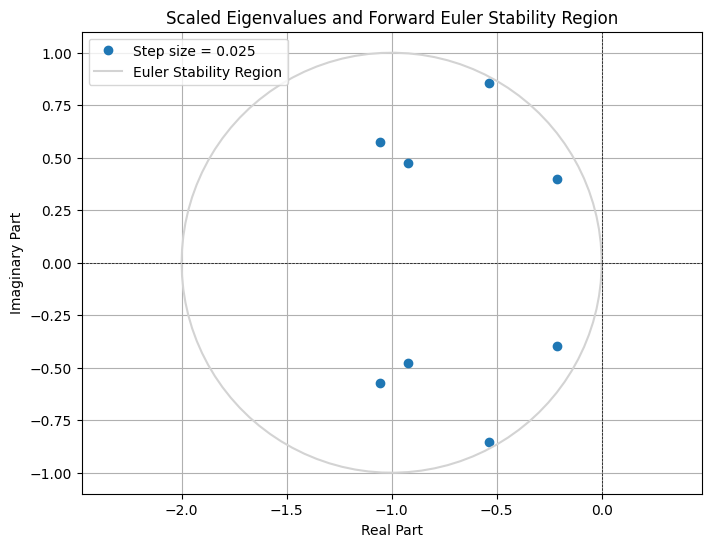

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

In [12]:
num_layers = 3
layer_shapes = [(u_dimension + 1, 32), (32, 16), (16, u_dimension)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

**Define the NNs**

In [13]:
# Possible normalization functions
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

In [ ]:
class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)


        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)
    
class DoubleCorrectionModel(eqx.Module):
    spike_neural_net: eqx.Module
    spike_readout_net: eqx.Module
    nospike_neural_net: eqx.Module
    nospike_readout_net: eqx.Module
    channel_params_normal: jnp.ndarray
    Na_gating_params_normal: jnp.ndarray
    K_gating_params_normal: jnp.ndarray
    Ca_gating_params_normal: jnp.ndarray
    powers_normal: jnp.ndarray


    def __init__(self, *, key, init_params, init_Na_gating_params, init_K_gating_params, init_Ca_gating_params, init_powers_normal, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.spike_neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.spike_readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.nospike_neural_net = SimpleNeuralNet(key=k3, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.nospike_readout_net = ReadoutNet(key=k4, u_dimension=u_dimension)
        self.channel_params_normal = init_params
        self.Na_gating_params_normal = init_Na_gating_params
        self.K_gating_params_normal = init_K_gating_params
        self.Ca_gating_params_normal = init_Ca_gating_params
        self.powers_normal = init_powers_normal



**Define the simulation and the loss**

In [ ]:
dt = 0.025
dv_treshold = 0.5


def simulate_full_trace(spike_neural_net, spike_readout_net, nospike_neural_net, nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr = None):
    def cond_fn(carry):
        t, _, _, _, diff, _ = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff, prev_voltage = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        #voltage_normalized = softsign_transform(voltage)
        #voltage_normalized = tempered_tanh(voltage)


        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        # Spike/Nospike?
        dv = jnp.abs(voltage - prev_voltage)
        use_spike_net = dv > dv_treshold
        
        # Compute add_current using spike/nospike NNs
        neural_net_output = jax.lax.cond(use_spike_net, lambda: spike_neural_net(inputs), lambda: nospike_neural_net(inputs))
        u_time_constant = jax.lax.cond(use_spike_net, lambda: spike_u_time_constant, lambda: nospike_u_time_constant)
        u_new = u + dt*neural_net_output / u_time_constant

        readout_net_output = jax.lax.cond(use_spike_net, lambda: spike_readout_net(u_new), lambda: nospike_readout_net(u_new))
        add_current = readout_net_output.squeeze()
        



        total_current = current[t] + add_current * added_curr_std
        state, rec = step_fn(state, total_current)
        rec_voltage = rec[0]



      
        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(neural_net_output)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses), new_diff, voltage)


    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses), 0.0, initial_state["v"][0].squeeze())

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses), _, _ = final_carry

    return recs, adds, us, nn_reses

In [ ]:
cost_fn_power = 1.0
scale = 0.05

lower_powers = jnp.array([2.8, 0.99, 3.8])
upper_powers = jnp.array([3.2, 1.01, 4.2])

transform_powers, inv_transform_powers = transform_uniform_to_normal(lower_powers, upper_powers)
sample_powers = get_prior(lower_powers, upper_powers, transform_powers)

lower_gatings = jnp.concatenate([jnp.full((20,), -0.1), jnp.full((50,), -0.1), jnp.full((10,), -1.0)]) # m_gate, h_gate, n_gate, u_inf, tau_u
upper_gatings = jnp.concatenate([jnp.full((20,), 0.1), jnp.full((50,), 0.1), jnp.full((10,), 1.0)])

transform_gatings, inv_transform_gatings = transform_uniform_to_normal(lower_gatings, upper_gatings)
sample_gatings = get_prior(lower_gatings, upper_gatings, transform_gatings)

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr=300, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0, add_reg = 0.0, gate_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)
    inv_powers = inv_transform_powers(model.powers_normal)
    inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
    inv_Na_gating_params = inv_gating_params[:40]
    inv_K_gating_params = inv_gating_params[40:60]
    inv_Ca_gating_params = inv_gating_params[60:80]


    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4]) #powers = inv_powers

    # Run simulation
    preds, additional_currents, _, _ = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))
    dtw_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)
    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    gate_loss = jnp.sum(jnp.abs(inv_Na_gating_params)) + jnp.sum(jnp.abs(inv_K_gating_params))
    
    return dtw_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg + add_loss * add_reg + gate_reg * gate_loss

**Initialize and train**

In [ ]:
u_dimension = 8
np.random.seed(42)
n_particles = 300

master_key = jax.random.PRNGKey(0)
key1, key2, key3, key4, key5 = jax.random.split(master_key, num = 5)
keys = jax.random.split(master_key, num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)

# Different, random u_time_constant vectors
log_uniform_samples = jax.random.uniform(key1, shape=(u_dimension,), minval=np.log(1), maxval=np.log(100.0))
nospike_u_time_constant = jnp.exp(log_uniform_samples)

log_uniform_samples = jax.random.uniform(key2, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
spike_u_time_constant = jnp.exp(log_uniform_samples)

added_curr_std = 1.0/10.0


thr = None


# Setup for learning rate scheduler
initial_lr = 3e-3 #15e-4
decay_factor = 0.99
transition_steps = 1  # decay after every epoch
decay_start = 100 
decay_end = 250 

# Initialize n_particles different parameter sets
opt_params = jax.vmap(sample_prior)(
    jax.random.split(key3, n_particles)
)
init_powers = jax.vmap(sample_powers)(
    jax.random.split(key4, n_particles)
)
init_gating_params = jax.vmap(sample_gatings)(
    jax.random.split(key5, n_particles)
)

init_Na_gating_params = init_gating_params[:,:40]
init_K_gating_params = init_gating_params[:,40:60]
init_Ca_gating_params = init_gating_params[:,60:80]



def initialize_model(key, init_params, Na_gating_params, K_gating_params, Ca_gating_params, powers, u_dimension, W_matrices, epsilon):
    model = DoubleCorrectionModel(
        key=key,
        init_params=init_params,
        init_Na_gating_params=Na_gating_params,
        init_K_gating_params=K_gating_params,
        init_Ca_gating_params=Ca_gating_params,
        init_powers_normal=powers,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model


models = jax.vmap(initialize_model, in_axes=(0, 0, 0, 0, 0, 0, None, None, None))(
    keys, opt_params, init_Na_gating_params, init_K_gating_params, init_Ca_gating_params, init_powers, u_dimension, W_matrices, epsilon
)

# Scheduler
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

# Possible optimizers
adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(optax.scale_by_lbfgs(memory_size = 6), optax.scale(-1e-3))
adamw_optimizer = optax.adamw(learning_rate=custom_schedule, weight_decay=1e-4)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adamw_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)


# Loss for optimization
def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0, add_reg = 0.0, gate_reg=0.0)
        return loss


grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))


# Set up the cell
cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params = jnp.zeros(20), use_CaT=True, use_CaL=False, use_Km=True)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

In [71]:
# Normalizing, scaling or clipping gradients
def clip_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling
    return jax.tree_util.tree_map(clip_leaf, grads)

def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads

def clip_network_gradients(grads, max_norm=1.0, eps=1e-8):
    def clip_leaf(grad):
        if grad.ndim < 2:
            return grad  # Skip biases or scalars
        flat = grad.reshape((grad.shape[0], -1))
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    def clip_net(net_grads):
        return jax.tree_util.tree_map(clip_leaf, net_grads)

    grads = eqx.tree_at(lambda g: g.spike_neural_net, grads, clip_net(grads.spike_neural_net))
    grads = eqx.tree_at(lambda g: g.spike_readout_net, grads, clip_net(grads.spike_readout_net))
    grads = eqx.tree_at(lambda g: g.nospike_neural_net, grads, clip_net(grads.nospike_neural_net))
    grads = eqx.tree_at(lambda g: g.nospike_readout_net, grads, clip_net(grads.nospike_readout_net))

    return grads

def normalize_gradients(grads, beta=1.0, eps=1e-8):
    def normalize_leaf(grad):
        norm = jnp.linalg.norm(grad, axis=1, keepdims=True)
        return grad / (norm ** beta + eps)

    grads = jax.tree_util.tree_map(normalize_leaf, grads)
    return grads

def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_spike, lr_nospike, lr_channel, lr_gates, lr_powers):
    def scale_tree(tree, factor):
        return jax.tree_util.tree_map(lambda x: x * factor, tree)

    grads_scaled = grads

    grads_scaled = eqx.tree_at(lambda g: g.spike_neural_net, grads_scaled,
                            scale_tree(grads.spike_neural_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.spike_readout_net, grads_scaled,
                            scale_tree(grads.spike_readout_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_neural_net, grads_scaled,
                            scale_tree(grads.nospike_neural_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_readout_net, grads_scaled,
                            scale_tree(grads.nospike_readout_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.channel_params_normal, grads_scaled,
                            grads.channel_params_normal * lr_channel)
    grads_scaled = eqx.tree_at(lambda g: g.Na_gating_params_normal, grads_scaled,
                            grads.Na_gating_params_normal * lr_gates)
    grads_scaled = eqx.tree_at(lambda g: g.K_gating_params_normal, grads_scaled,
                            grads.K_gating_params_normal * lr_gates)
    grads_scaled = eqx.tree_at(lambda g: g.Ca_gating_params_normal, grads_scaled,
                            grads.Ca_gating_params_normal * lr_gates)
    grads_scaled = eqx.tree_at(lambda g: g.Ca_gating_params_normal, grads_scaled,
                            grads.Ca_gating_params_normal * lr_gates)
    grads_scaled = eqx.tree_at(lambda g: g.powers_normal, grads_scaled,
                            grads.powers_normal * lr_powers)

    return grads_scaled

In [72]:
num_epochs = 300
mean_losses = []

# Storing the best models and their losses during training
best_gate_losses = jnp.full((1,), jnp.inf)
best_gate_models = models  # Start with the initial models as best
grads_list = []
model_snapshots = []


for epoch in range(num_epochs):

    loss, grads = grad_fn(models)
    grads_list.append(grads)
        
    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_spike=10, lr_nospike = 1e-2, lr_channel=1.0)
    grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_spike=1.0, lr_nospike = 1.0, lr_channel=1.0, lr_gates=0.0, lr_powers=0.0)



    improved = loss < best_gate_losses
    best_gate_losses = jnp.where(improved, loss, best_gate_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_gate_models = jax.tree_util.tree_map(replace_if_improved, models, best_gate_models)

    mask = ~jnp.isnan(loss)
    mean_loss = jnp.sum(loss[mask]) / jnp.sum(mask)
    mean_losses.append(mean_loss)

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)
    model_snapshots.append(jax.tree_util.tree_map(lambda x: x.copy(), models))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {mean_loss:.6f}, Median Loss {jnp.median(loss[mask]):.6f}, Min Loss: {jnp.min(loss[mask]):.6f}")

        print(jnp.median(jnp.linalg.norm(grads.channel_params_normal, axis=1)), jnp.median(jnp.linalg.norm(grads.Na_gating_params_normal, axis=1)), jnp.median(jnp.linalg.norm(grads.K_gating_params_normal, axis=1)), jnp.median(jnp.linalg.norm(grads.Ca_gating_params_normal, axis=1)),
          jnp.median(jnp.linalg.norm(grads.powers_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.bias, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 828.683185, Median Loss 866.671030, Min Loss: 229.996651
9.999999999174353 0.029828487439203147 0.12724400268663055 0.022727978346330835 0.0 6.917628159178443 9.99999999993412 9.236868609513118 9.999999999902741 9.019452926837534 9.99999999996848 7.556515213506159 9.999999997599765 9.999999999856069 9.999999999089646 7.539089303415608 9.99999999999505 9.882235131472315 9.99999999999277 9.066778210964324 9.999999999998716 7.8762122759370445 9.99999999999799 9.999999999999822 9.999999999999105
Epoch 10, Mean Loss: 526.901364, Median Loss 493.675085, Min Loss: 211.714245
9.999999999789042 39.99300890310928 26.15941050323255 5.653778995241317 0.0 8.107443990022691 9.999999999993939 9.999999999891967 9.999999999988814 9.827820104699532 9.999999999995548 9.2223194446228 9.999999998311964 9.999999999993324 9.999999999285075 7.696520328799572 9.999999999999902 9.72303087783404 9.999999999999877 9.181743767644942 9.999999999999943 8.809520071760247 9.999999999999767 9.999999

In [48]:
nan_mask = jnp.isnan(grads_list[num_epochs-1].channel_params_normal)

# Get indices where the mask is True
nan_indices = jnp.argwhere(nan_mask)
print("Not successfully trained models:", int(len(nan_indices)/15))

Not successfully trained models: 1


/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

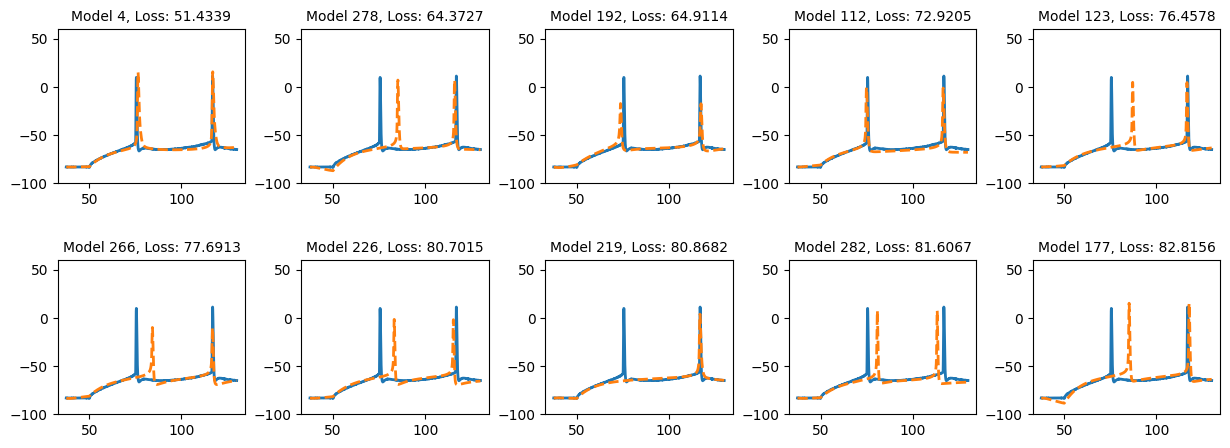

In [ ]:
#25: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

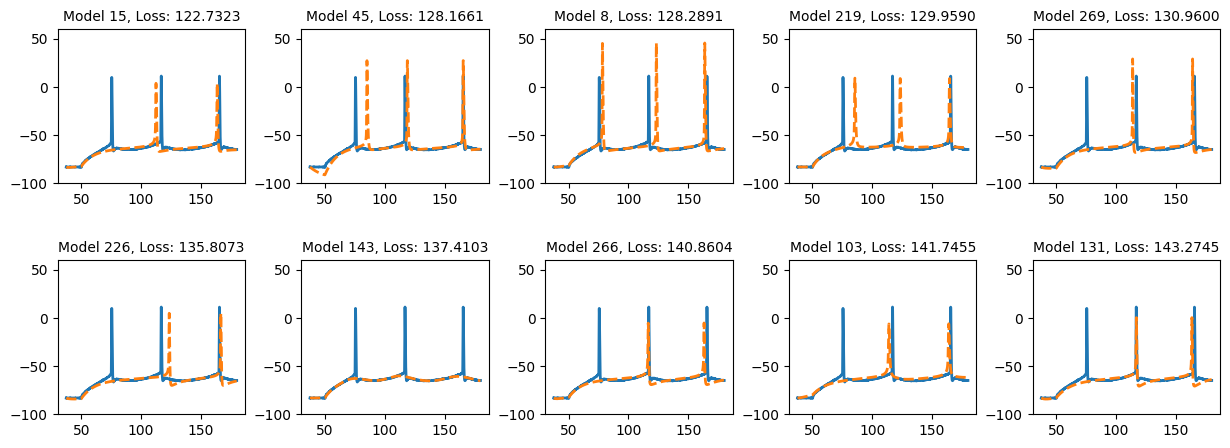

In [ ]:
#25: t=180.0, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

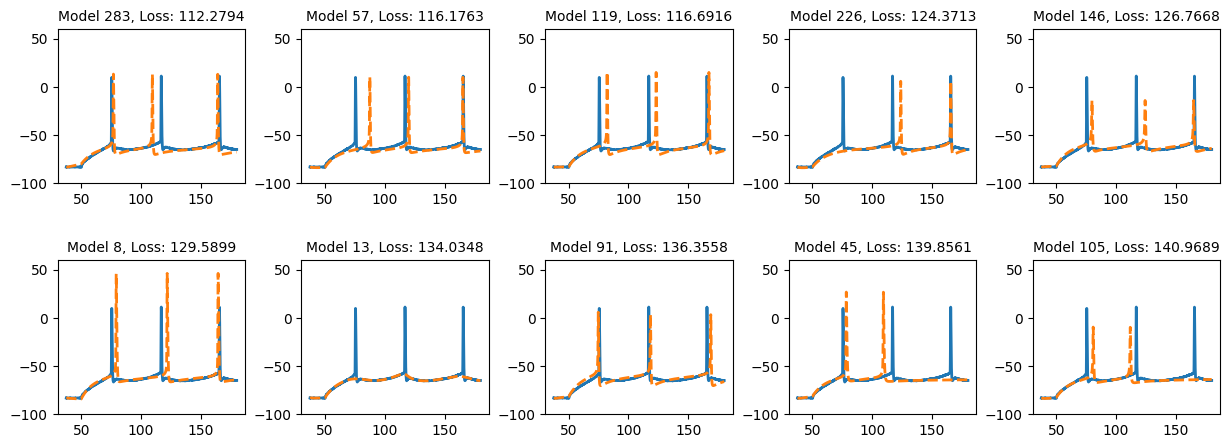

In [ ]:
#25: t=180.0, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

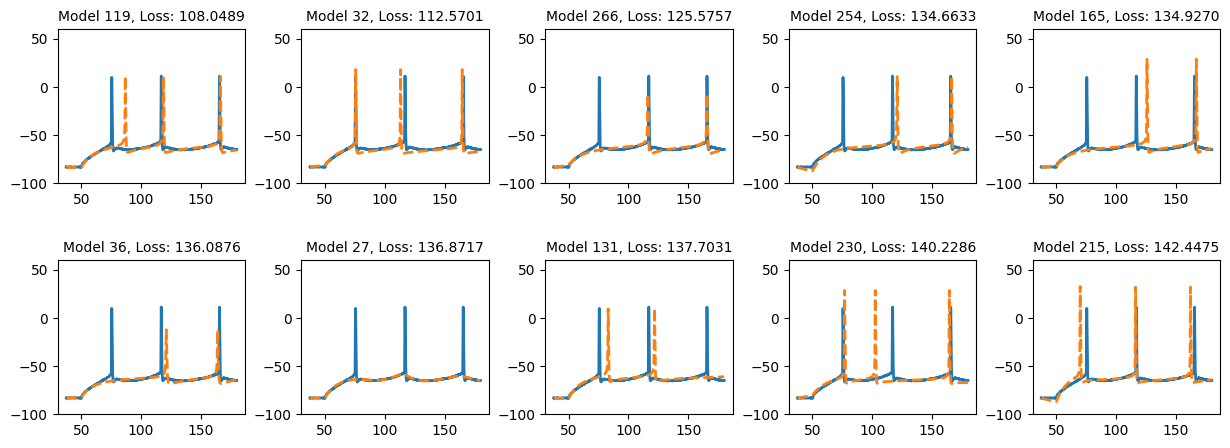

In [ ]:
#25: t=180.0, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km, with CaL
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=True, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

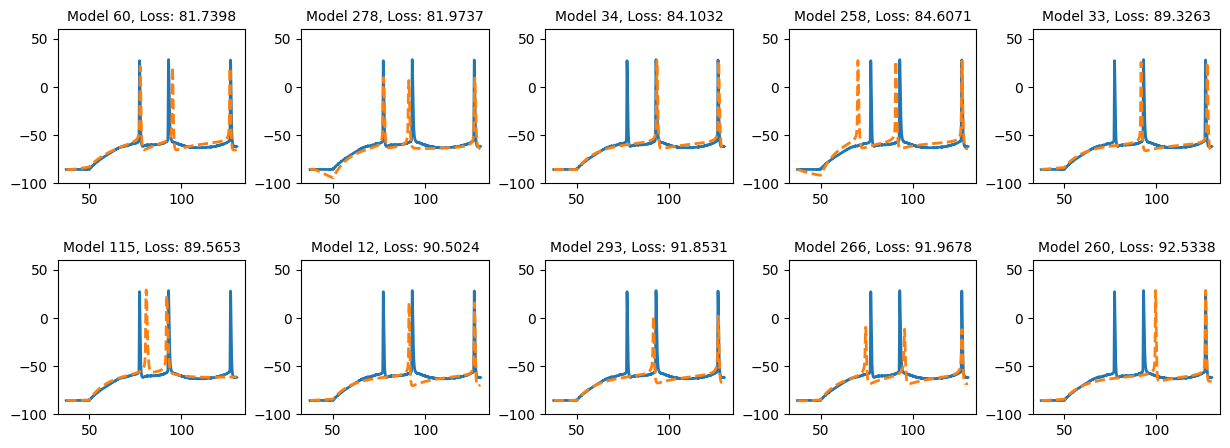

In [ ]:
#32: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

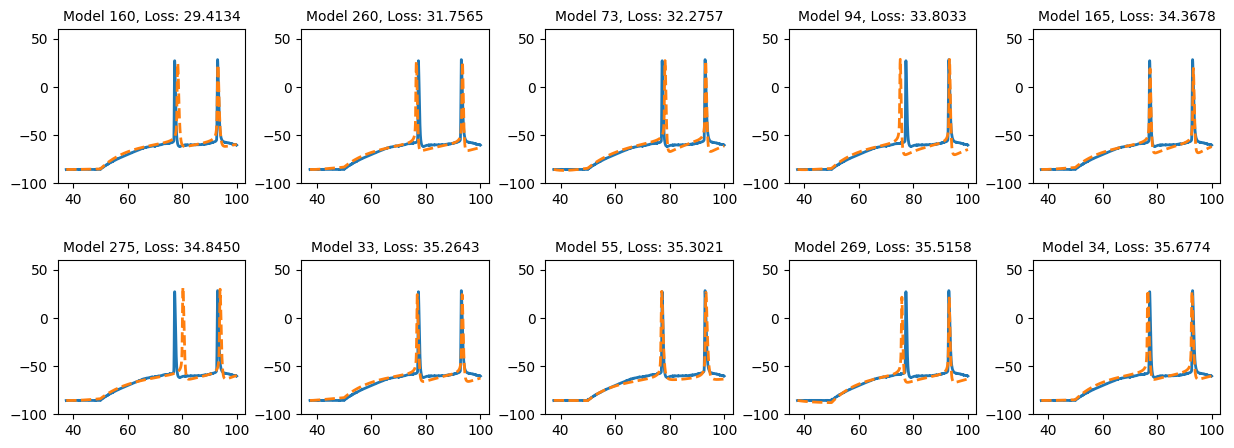

In [ ]:
#32: t=100.0, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

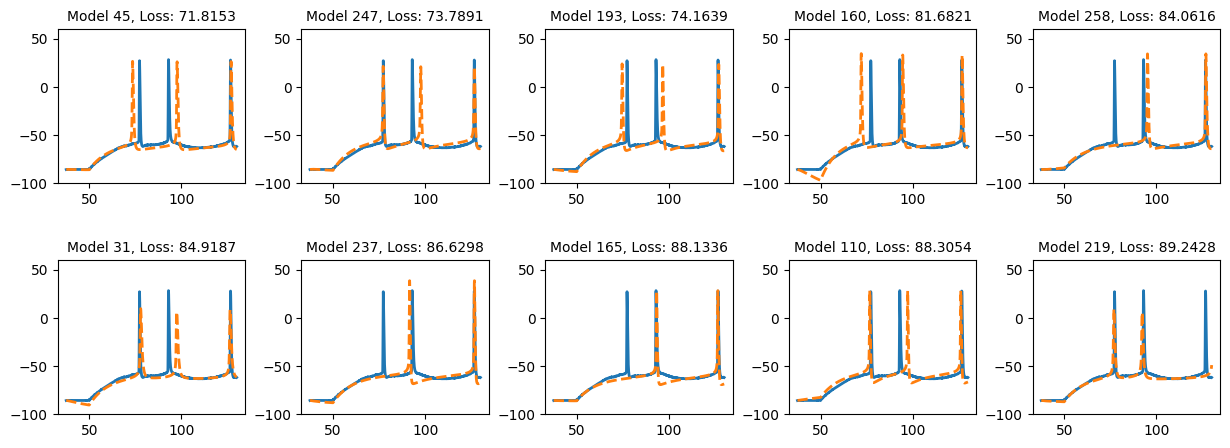

In [ ]:
#32: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

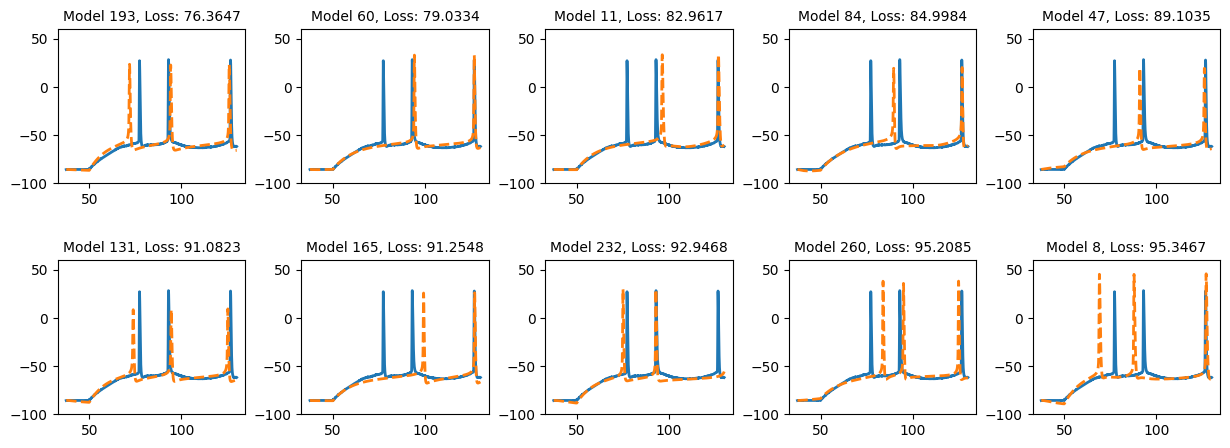

In [ ]:
#32: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km, with CaL
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=True, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

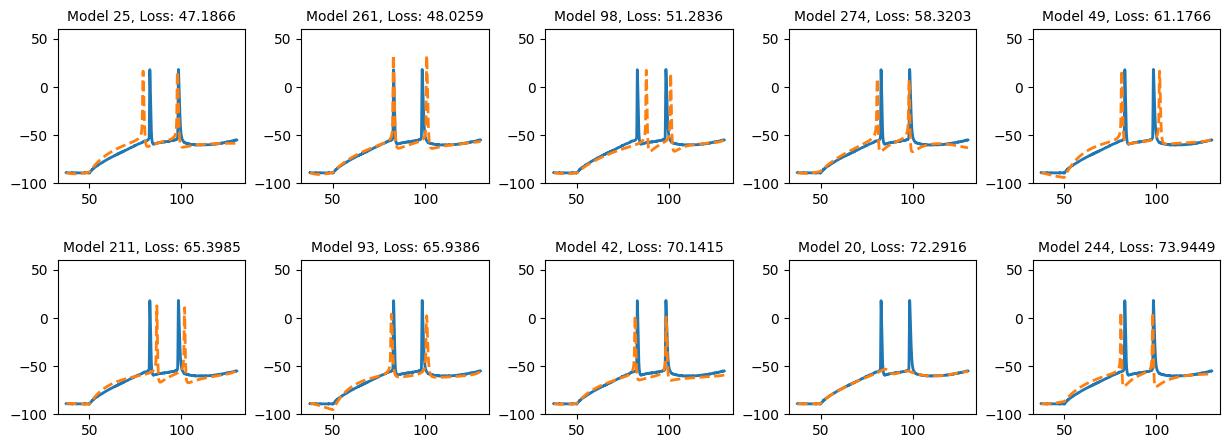

In [ ]:
#86: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

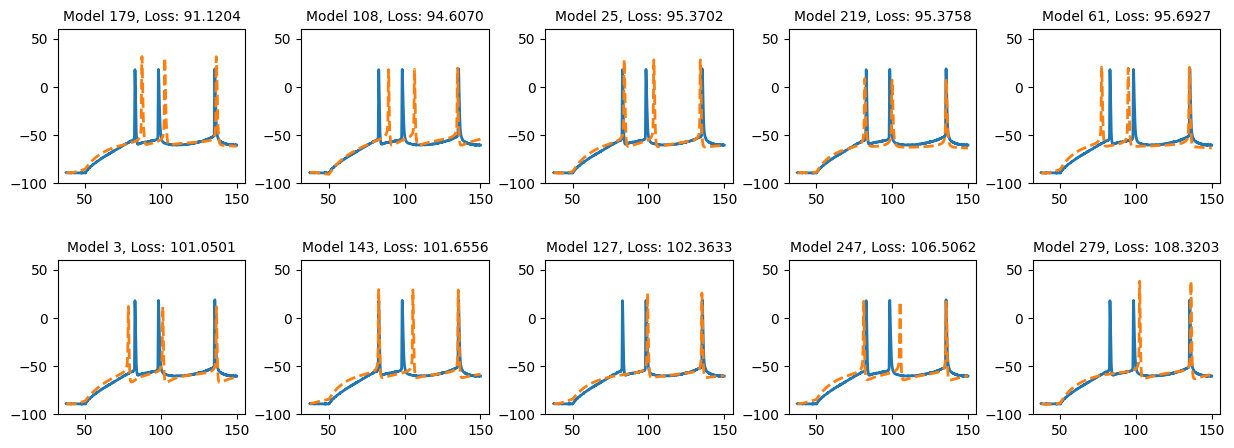

In [ ]:
#86: t=150, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

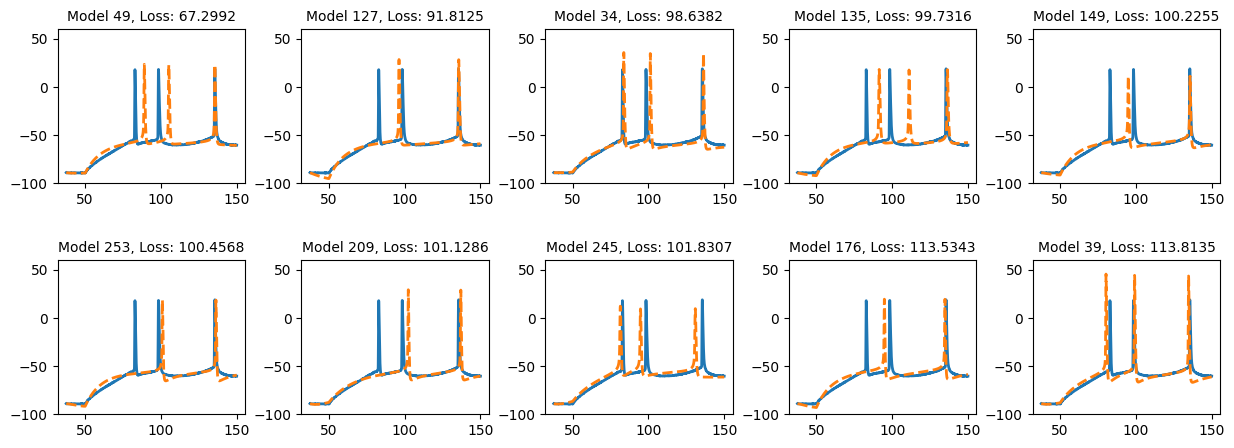

In [ ]:
#86: t=150, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

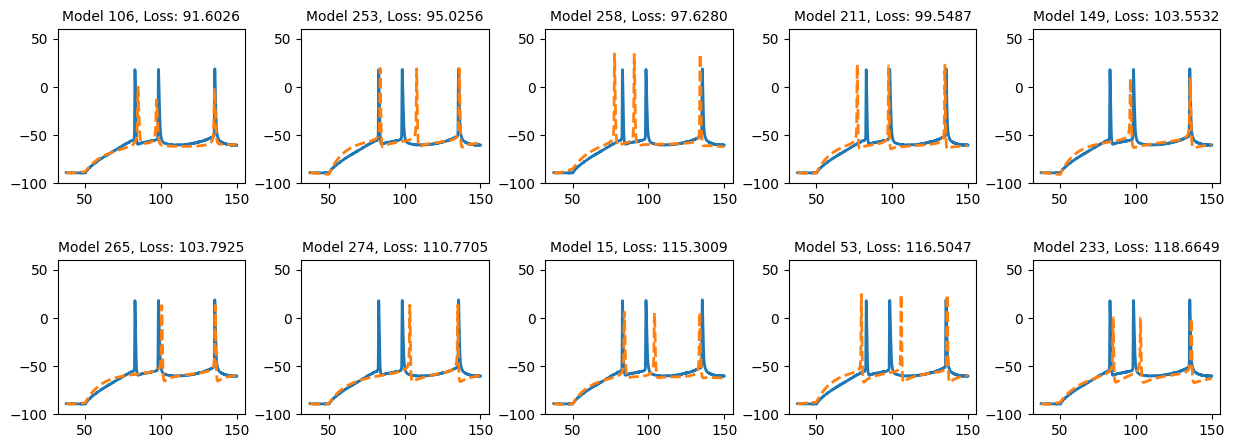

In [ ]:
#86: t=150, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km,with CaL
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=True, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

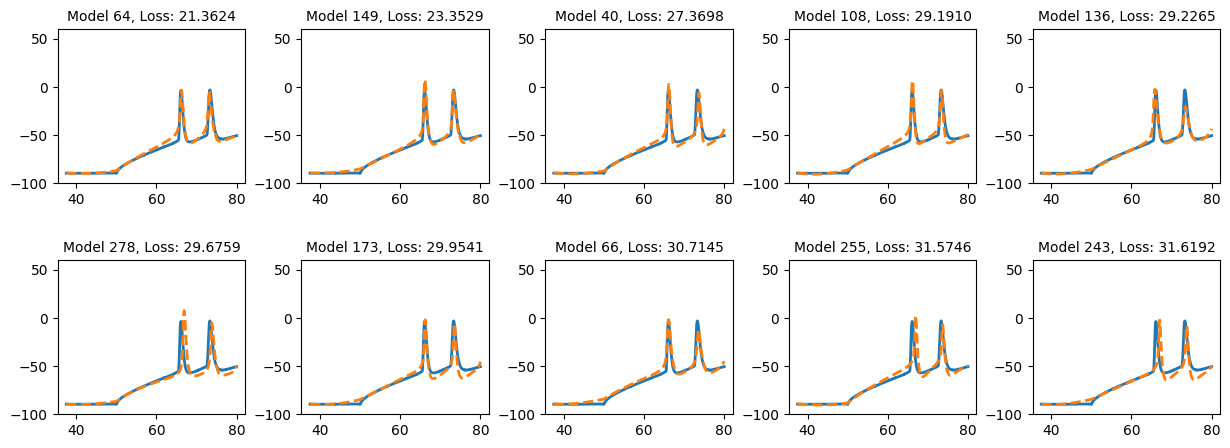

In [ ]:
#79: t=80, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

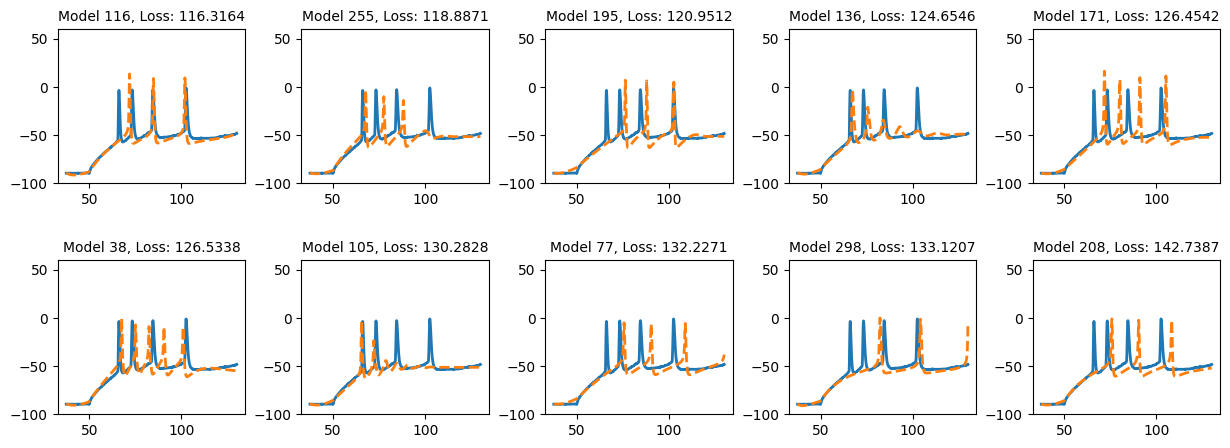

In [ ]:
#79: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

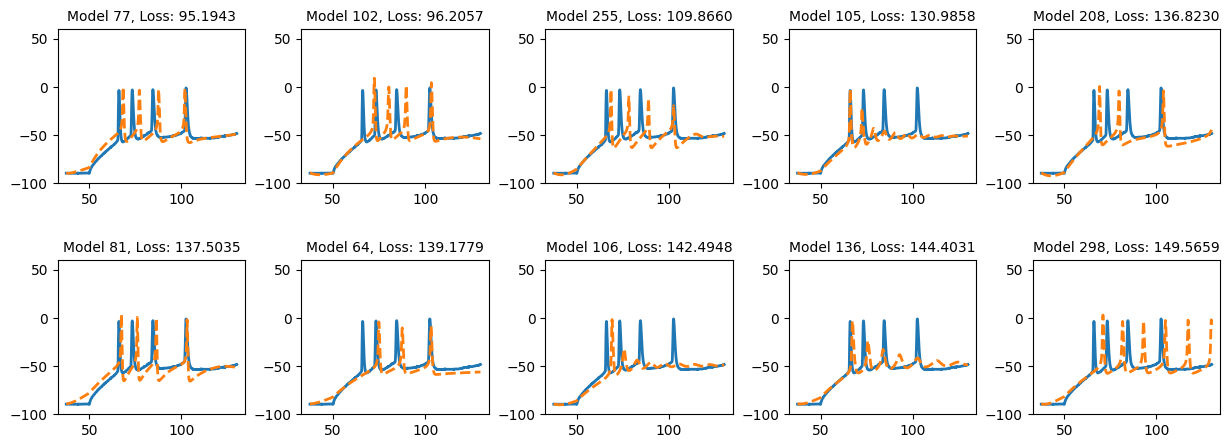

In [ ]:
#79: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

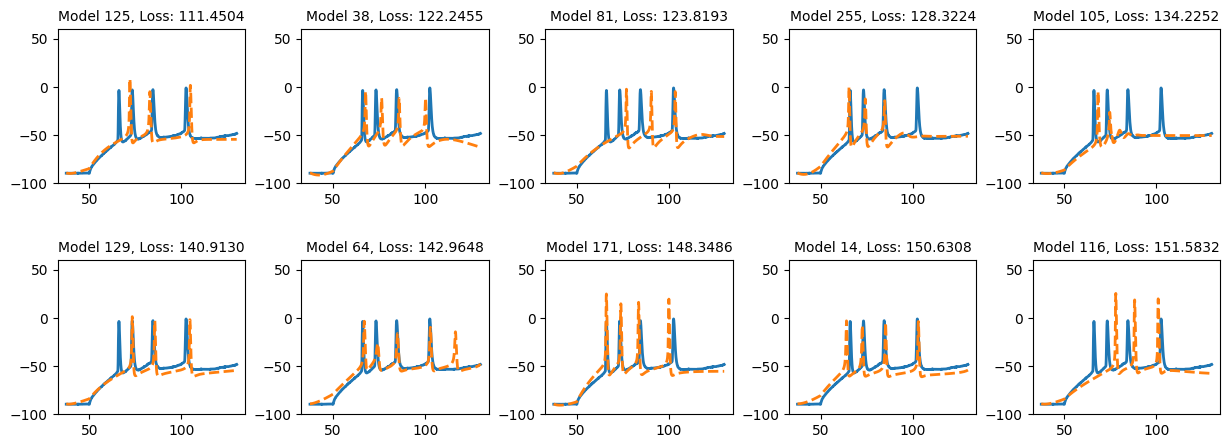

In [ ]:
#79: t=130, no powers, lr3e-3, 0.1, 0.1, 1.0 ranges for transforms, CaT, transformed gating params + CaT gating params, new na bounds, with Km, with CaL
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)
        inv_powers = inv_transform_powers(model.powers_normal)

        inv_gating_params = inv_transform_gatings(jnp.concatenate([model.Na_gating_params_normal, model.K_gating_params_normal, model.Ca_gating_params_normal]))
        inv_Na_gating_params = inv_gating_params[:40]
        inv_K_gating_params = inv_gating_params[40:60]
        inv_Ca_gating_params = inv_gating_params[60:80]

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params=jnp.zeros(20) , use_CaT=True, use_CaL=True, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()


        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = True, params = opt_inv_params, Na_gating_params = inv_Na_gating_params, K_gating_params = inv_K_gating_params, Ca_gating_params = inv_Ca_gating_params, powers = [3,1,4])


        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)